# 📊 Exploratory Data Analysis (EDA) - UIT-ViSD4SA Dataset

## 🎯 **Mô tả Dataset**

### Giới thiệu
**UIT-ViSD4SA** (Vietnamese Smartphone Sentiment Dataset for Aspect-Based Sentiment Analysis) là một bộ dữ liệu tiếng Việt được xây dựng nhằm phục vụ nghiên cứu về Phân tích cảm xúc theo khía cạnh (Aspect-Based Sentiment Analysis - ABSA).

### Đặc điểm chính:
- **Ngôn ngữ:** Tiếng Việt
- **Miền ứng dụng:** Đánh giá sản phẩm điện thoại thông minh (Smartphone Reviews)
- **Nguồn dữ liệu:** Các bình luận/đánh giá từ các trang thương mại điện tử Việt Nam

### Cấu trúc dữ liệu:
Mỗi mẫu dữ liệu bao gồm:
- **text:** Nội dung đánh giá sản phẩm
- **labels:** Danh sách các annotation với định dạng `[start, end, "ASPECT#SENTIMENT"]`
  - `start`: Vị trí bắt đầu của span
  - `end`: Vị trí kết thúc của span
  - `ASPECT#SENTIMENT`: Nhãn khía cạnh và cảm xúc

### Các Aspect (Khía cạnh):
| Aspect | Mô tả |
|--------|-------|
| GENERAL | Đánh giá chung về sản phẩm |
| BATTERY | Đánh giá về pin |
| CAMERA | Đánh giá về camera/máy ảnh |
| DESIGN | Đánh giá về thiết kế |
| FEATURES | Đánh giá về các tính năng |
| PERFORMANCE | Đánh giá về hiệu năng |
| PRICE | Đánh giá về giá cả |
| SCREEN | Đánh giá về màn hình |
| SER&ACC | Đánh giá về dịch vụ và phụ kiện |
| STORAGE | Đánh giá về bộ nhớ |

### Các Sentiment (Cảm xúc):
| Sentiment | Mô tả |
|-----------|-------|
| POSITIVE | Tích cực |
| NEGATIVE | Tiêu cực |
| NEUTRAL | Trung lập |

---
## 1️⃣ Import Libraries & Load Data

In [1]:
# Import thư viện cần thiết
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Cài đặt style cho biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palette
COLORS = {
    'primary': '#667eea',
    'secondary': '#764ba2',
    'positive': '#10b981',
    'negative': '#ef4444',
    'neutral': '#6b7280',
    'palette': ['#667eea', '#764ba2', '#f093fb', '#f5576c', '#4facfe', '#00f2fe', '#43e97b', '#fa709a']
}



In [2]:
def load_jsonl(filepath):
    """Load data từ file JSONL"""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line.strip()))
    return data

# Load các file dữ liệu
train_data = load_jsonl('train.jsonl')
dev_data = load_jsonl('dev.jsonl')
test_data = load_jsonl('test.jsonl')

# Tổng hợp toàn bộ dữ liệu
all_data = train_data + dev_data + test_data

print(f"📁 Số lượng samples:")
print(f"   ├── Train: {len(train_data):,} samples")
print(f"   ├── Dev:   {len(dev_data):,} samples")
print(f"   ├── Test:  {len(test_data):,} samples")
print(f"   └── Total: {len(all_data):,} samples")

📁 Số lượng samples:
   ├── Train: 7,785 samples
   ├── Dev:   1,112 samples
   ├── Test:  2,225 samples
   └── Total: 11,122 samples


In [3]:
# Xem thử một số samples
print("📝 Ví dụ 3 samples đầu tiên:\n")
for i, sample in enumerate(train_data[:3], 1):
    print(f"Sample {i}:")
    print(f"  Text: {sample['text'][:100]}..." if len(sample['text']) > 100 else f"  Text: {sample['text']}")
    print(f"  Labels: {sample['labels']}")
    print()

📝 Ví dụ 3 samples đầu tiên:

Sample 1:
  Text: Pin Sài tầm 50h cho pin 100/100. Camera ổn ... tất cả đều OK ... nhân viên thế giới di động trần văn...
  Labels: [[0, 31, 'BATTERY#POSITIVE'], [33, 42, 'CAMERA#POSITIVE'], [47, 60, 'GENERAL#POSITIVE'], [65, 181, 'SER&ACC#POSITIVE']]

Sample 2:
  Text: Lag và hao pin là cái tóm tắt về máy. Sam làm tệ quá, không bằng mấy con tàu cùng phân...
  Labels: [[0, 3, 'PERFORMANCE#NEGATIVE'], [8, 15, 'BATTERY#NEGATIVE'], [45, 106, 'GENERAL#NEGATIVE']]

Sample 3:
  Text: Tất cả đều ổn ngoại trừ lúc máy nóng lên thì pin tụt nhanh hơn tụt quần haizz. Cam chụp cũng gọi là ...
  Labels: [[79, 109, 'CAMERA#NEUTRAL'], [111, 169, 'BATTERY#POSITIVE'], [28, 71, 'BATTERY#NEGATIVE']]



---
## 2️⃣ Trích xuất và phân tích Labels

In [4]:
def extract_labels(data):
    """Trích xuất thông tin labels từ dữ liệu"""
    aspects = []
    sentiments = []
    aspect_sentiments = []
    
    for sample in data:
        for label in sample['labels']:
            # label = [start, end, "ASPECT#SENTIMENT"]
            aspect_sentiment = label[2]
            aspect, sentiment = aspect_sentiment.split('#')
            
            aspects.append(aspect)
            sentiments.append(sentiment)
            aspect_sentiments.append(aspect_sentiment)
    
    return aspects, sentiments, aspect_sentiments

# Trích xuất từ toàn bộ dữ liệu
all_aspects, all_sentiments, all_aspect_sentiments = extract_labels(all_data)

# Trích xuất từ từng phần
train_aspects, train_sentiments, train_as = extract_labels(train_data)
dev_aspects, dev_sentiments, dev_as = extract_labels(dev_data)
test_aspects, test_sentiments, test_as = extract_labels(test_data)

print(f"📊 Thống kê Labels:")
print(f"   ├── Tổng số labels: {len(all_aspect_sentiments):,}")
print(f"   ├── Số unique Aspects: {len(set(all_aspects))}")
print(f"   ├── Số unique Sentiments: {len(set(all_sentiments))}")
print(f"   └── Số unique Aspect-Sentiment pairs: {len(set(all_aspect_sentiments))}")

📊 Thống kê Labels:
   ├── Tổng số labels: 35,396
   ├── Số unique Aspects: 10
   ├── Số unique Sentiments: 3
   └── Số unique Aspect-Sentiment pairs: 30


In [5]:
# Đếm số lượng từng loại
aspect_counts = Counter(all_aspects)
sentiment_counts = Counter(all_sentiments)
as_counts = Counter(all_aspect_sentiments)

print("📈 Phân bố Aspects:")
for aspect, count in aspect_counts.most_common():
    print(f"   {aspect}: {count:,} ({count/len(all_aspects)*100:.1f}%)")

print("\n📈 Phân bố Sentiments:")
for sentiment, count in sentiment_counts.most_common():
    print(f"   {sentiment}: {count:,} ({count/len(all_sentiments)*100:.1f}%)")

📈 Phân bố Aspects:
   GENERAL: 8,057 (22.8%)
   PERFORMANCE: 6,906 (19.5%)
   BATTERY: 5,630 (15.9%)
   FEATURES: 3,994 (11.3%)
   CAMERA: 3,117 (8.8%)
   SER&ACC: 2,635 (7.4%)
   DESIGN: 2,141 (6.0%)
   PRICE: 1,389 (3.9%)
   SCREEN: 1,382 (3.9%)
   STORAGE: 145 (0.4%)

📈 Phân bố Sentiments:
   POSITIVE: 21,832 (61.7%)
   NEGATIVE: 11,350 (32.1%)
   NEUTRAL: 2,214 (6.3%)


---
## 3️⃣ Visualizations - Phân bố Data

### 3.1 Phân bố Data theo Split (Train/Dev/Test)

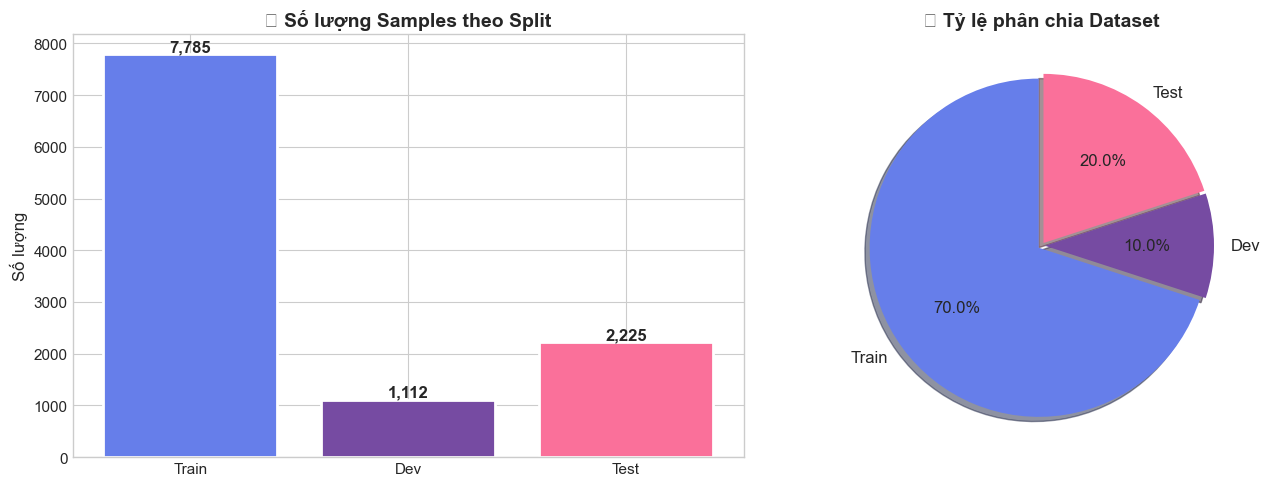

In [6]:
# Biểu đồ phân bố số samples theo Split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
splits = ['Train', 'Dev', 'Test']
counts = [len(train_data), len(dev_data), len(test_data)]
colors = [COLORS['primary'], COLORS['secondary'], '#fa709a']

bars = axes[0].bar(splits, counts, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('📊 Số lượng Samples theo Split', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Số lượng', fontsize=12)

# Thêm giá trị trên mỗi cột
for bar, count in zip(bars, counts):
    axes[0].annotate(f'{count:,}', 
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom',
                     fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', colors=colors,
            explode=(0.02, 0.02, 0.02), shadow=True, startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('📊 Tỷ lệ phân chia Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### 3.2 Phân bố theo Aspect

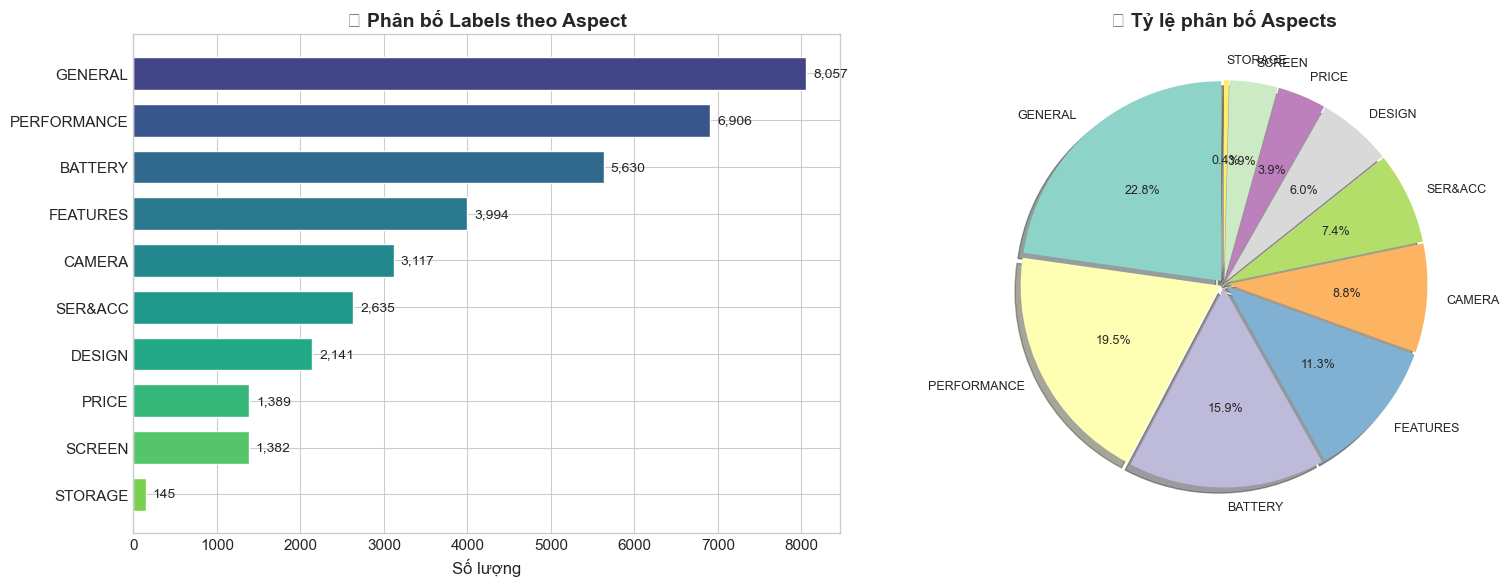

In [7]:
# Biểu đồ phân bố Aspects
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sắp xếp theo số lượng giảm dần
aspects_sorted = dict(aspect_counts.most_common())

# Horizontal bar chart
colors_gradient = plt.cm.viridis(np.linspace(0.2, 0.8, len(aspects_sorted)))
bars = axes[0].barh(list(aspects_sorted.keys())[::-1], list(aspects_sorted.values())[::-1], 
                    color=colors_gradient[::-1], edgecolor='white', height=0.7)
axes[0].set_title('📊 Phân bố Labels theo Aspect', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lượng', fontsize=12)

# Thêm giá trị
for bar in bars:
    width = bar.get_width()
    axes[0].annotate(f'{int(width):,}',
                     xy=(width, bar.get_y() + bar.get_height()/2),
                     xytext=(5, 0), textcoords='offset points',
                     ha='left', va='center', fontsize=10)

# Pie chart
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(aspects_sorted)))
wedges, texts, autotexts = axes[1].pie(
    list(aspects_sorted.values()), 
    labels=list(aspects_sorted.keys()),
    autopct='%1.1f%%', 
    colors=colors_pie,
    explode=[0.02]*len(aspects_sorted),
    shadow=True,
    startangle=90,
    textprops={'fontsize': 9}
)
axes[1].set_title('📊 Tỷ lệ phân bố Aspects', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### 3.3 Phân bố theo Sentiment

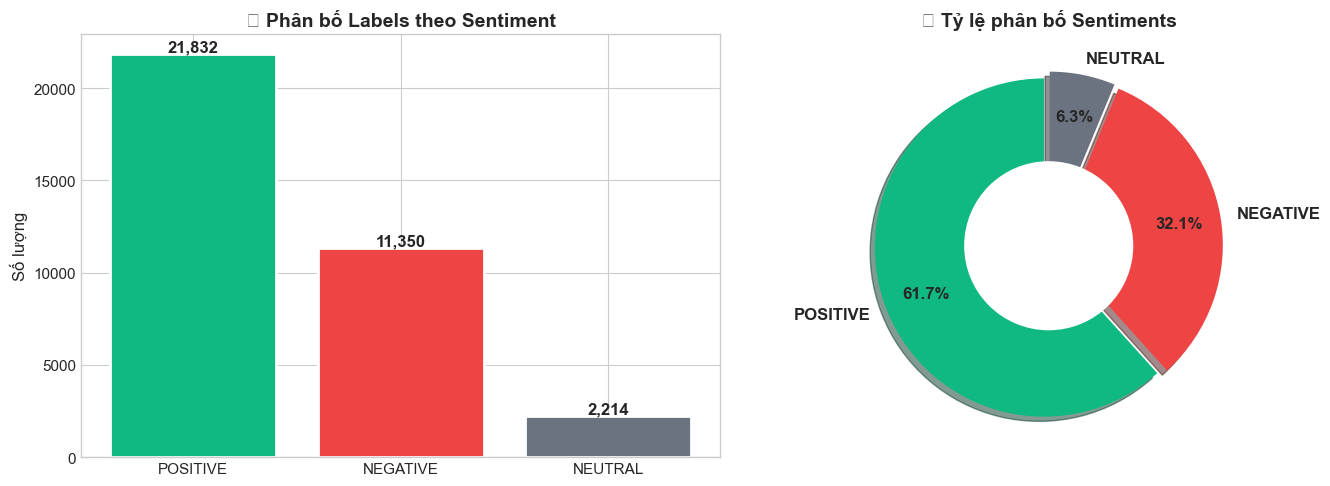

In [8]:
# Biểu đồ phân bố Sentiments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiments_sorted = {'POSITIVE': sentiment_counts['POSITIVE'],
                     'NEGATIVE': sentiment_counts['NEGATIVE'],
                     'NEUTRAL': sentiment_counts['NEUTRAL']}

sentiment_colors = [COLORS['positive'], COLORS['negative'], COLORS['neutral']]

# Bar chart
bars = axes[0].bar(list(sentiments_sorted.keys()), list(sentiments_sorted.values()), 
                   color=sentiment_colors, edgecolor='white', linewidth=2)
axes[0].set_title('📊 Phân bố Labels theo Sentiment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Số lượng', fontsize=12)

# Thêm giá trị
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f'{int(height):,}',
                     xy=(bar.get_x() + bar.get_width()/2, height),
                     ha='center', va='bottom',
                     fontsize=12, fontweight='bold')

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    list(sentiments_sorted.values()), 
    labels=list(sentiments_sorted.keys()),
    autopct='%1.1f%%', 
    colors=sentiment_colors,
    explode=(0.03, 0.03, 0.03),
    shadow=True,
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Tạo vòng tròn ở giữa để thành donut chart
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('📊 Tỷ lệ phân bố Sentiments', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### 3.4 Phân bố Sentiment theo từng Aspect (Stacked Bar Chart)

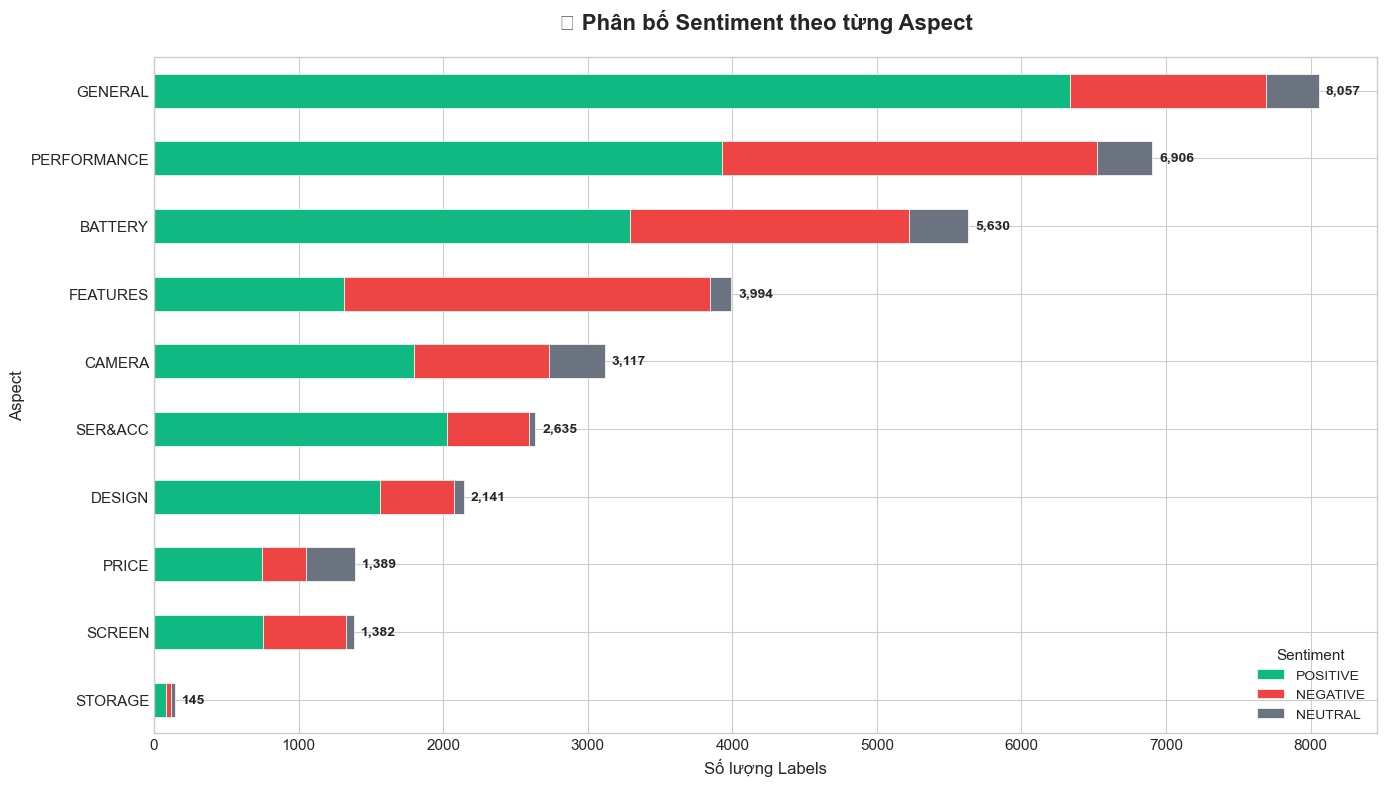

💾 Saved: aspect_sentiment_stacked.png


In [9]:
# Tạo DataFrame để phân tích Aspect-Sentiment
aspect_sentiment_df = pd.DataFrame({
    'Aspect': all_aspects,
    'Sentiment': all_sentiments
})

# Pivot table
pivot_counts = pd.crosstab(aspect_sentiment_df['Aspect'], aspect_sentiment_df['Sentiment'])
pivot_counts = pivot_counts.reindex(columns=['POSITIVE', 'NEGATIVE', 'NEUTRAL'])

# Sắp xếp theo tổng số labels
pivot_counts['Total'] = pivot_counts.sum(axis=1)
pivot_counts = pivot_counts.sort_values('Total', ascending=True)
pivot_counts = pivot_counts.drop('Total', axis=1)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))

pivot_counts.plot(kind='barh', stacked=True, ax=ax,
                  color=[COLORS['positive'], COLORS['negative'], COLORS['neutral']],
                  edgecolor='white', linewidth=0.5)

ax.set_title('📊 Phân bố Sentiment theo từng Aspect', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Số lượng Labels', fontsize=12)
ax.set_ylabel('Aspect', fontsize=12)
ax.legend(title='Sentiment', loc='lower right', fontsize=10)

# Thêm tổng số ở cuối mỗi bar
for i, (idx, row) in enumerate(pivot_counts.iterrows()):
    total = row.sum()
    ax.annotate(f'{int(total):,}', 
                xy=(total + 50, i),
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print("💾 Saved: aspect_sentiment_stacked.png")

In [10]:
# Hiển thị bảng thống kê chi tiết
print("📋 Bảng thống kê Aspect-Sentiment:")
display_df = pivot_counts.copy()
display_df['Total'] = display_df.sum(axis=1)
display_df = display_df.sort_values('Total', ascending=False)
print(display_df.to_markdown())

📋 Bảng thống kê Aspect-Sentiment:
| Aspect      |   POSITIVE |   NEGATIVE |   NEUTRAL |   Total |
|:------------|-----------:|-----------:|----------:|--------:|
| GENERAL     |       6338 |       1357 |       362 |    8057 |
| PERFORMANCE |       3926 |       2596 |       384 |    6906 |
| BATTERY     |       3290 |       1935 |       405 |    5630 |
| FEATURES    |       1312 |       2537 |       145 |    3994 |
| CAMERA      |       1801 |        930 |       386 |    3117 |
| SER&ACC     |       2027 |        565 |        43 |    2635 |
| DESIGN      |       1560 |        515 |        66 |    2141 |
| PRICE       |        743 |        310 |       336 |    1389 |
| SCREEN      |        751 |        573 |        58 |    1382 |
| STORAGE     |         84 |         32 |        29 |     145 |


### 3.5 Heatmap Aspect-Sentiment

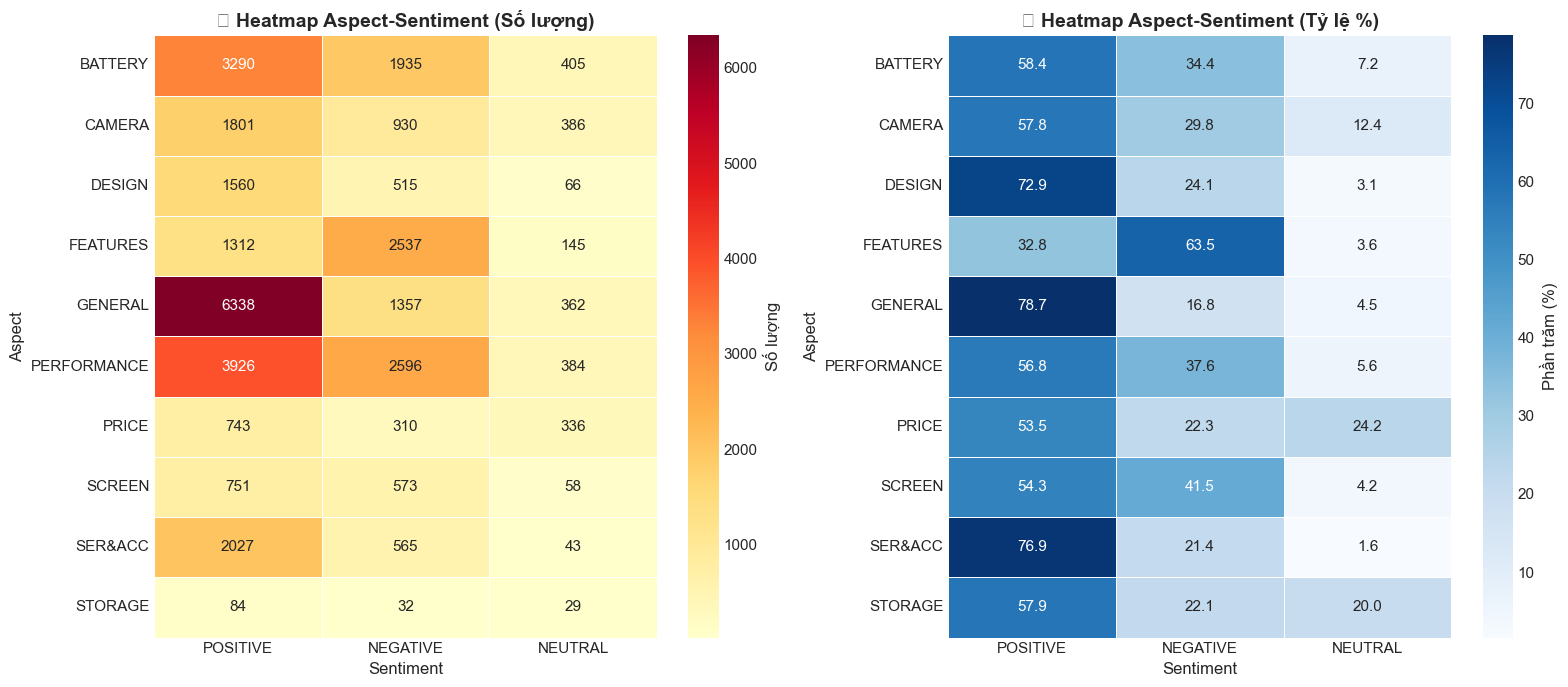

In [11]:
# Heatmap phân bố Aspect-Sentiment
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap với số lượng thực
pivot_heatmap = pd.crosstab(aspect_sentiment_df['Aspect'], aspect_sentiment_df['Sentiment'])
pivot_heatmap = pivot_heatmap.reindex(columns=['POSITIVE', 'NEGATIVE', 'NEUTRAL'])

sns.heatmap(pivot_heatmap, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Số lượng'})
axes[0].set_title('🔥 Heatmap Aspect-Sentiment (Số lượng)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Aspect', fontsize=12)

# Heatmap với tỷ lệ phần trăm (normalize theo hàng)
pivot_pct = pivot_heatmap.div(pivot_heatmap.sum(axis=1), axis=0) * 100

sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Phần trăm (%)'})
axes[1].set_title('📈 Heatmap Aspect-Sentiment (Tỷ lệ %)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Aspect', fontsize=12)

plt.tight_layout()
plt.show()


### 3.6 Phân bố độ dài Review

In [12]:
# Phân tích độ dài reviews
review_lengths = [len(sample['text']) for sample in all_data]
word_counts = [len(sample['text'].split()) for sample in all_data]
labels_per_review = [len(sample['labels']) for sample in all_data]

print("📏 Thống kê độ dài Review (characters):")
print(f"   Min: {min(review_lengths)}")
print(f"   Max: {max(review_lengths)}")
print(f"   Mean: {np.mean(review_lengths):.1f}")
print(f"   Median: {np.median(review_lengths):.1f}")
print(f"   Std: {np.std(review_lengths):.1f}")

print("\n📏 Thống kê số từ (words):")
print(f"   Min: {min(word_counts)}")
print(f"   Max: {max(word_counts)}")
print(f"   Mean: {np.mean(word_counts):.1f}")
print(f"   Median: {np.median(word_counts):.1f}")

print("\n🏷️ Thống kê số labels per review:")
print(f"   Min: {min(labels_per_review)}")
print(f"   Max: {max(labels_per_review)}")
print(f"   Mean: {np.mean(labels_per_review):.1f}")

📏 Thống kê độ dài Review (characters):
   Min: 10
   Max: 850
   Mean: 158.3
   Median: 128.0
   Std: 87.8

📏 Thống kê số từ (words):
   Min: 2
   Max: 205
   Mean: 36.0
   Median: 29.0

🏷️ Thống kê số labels per review:
   Min: 0
   Max: 11
   Mean: 3.2


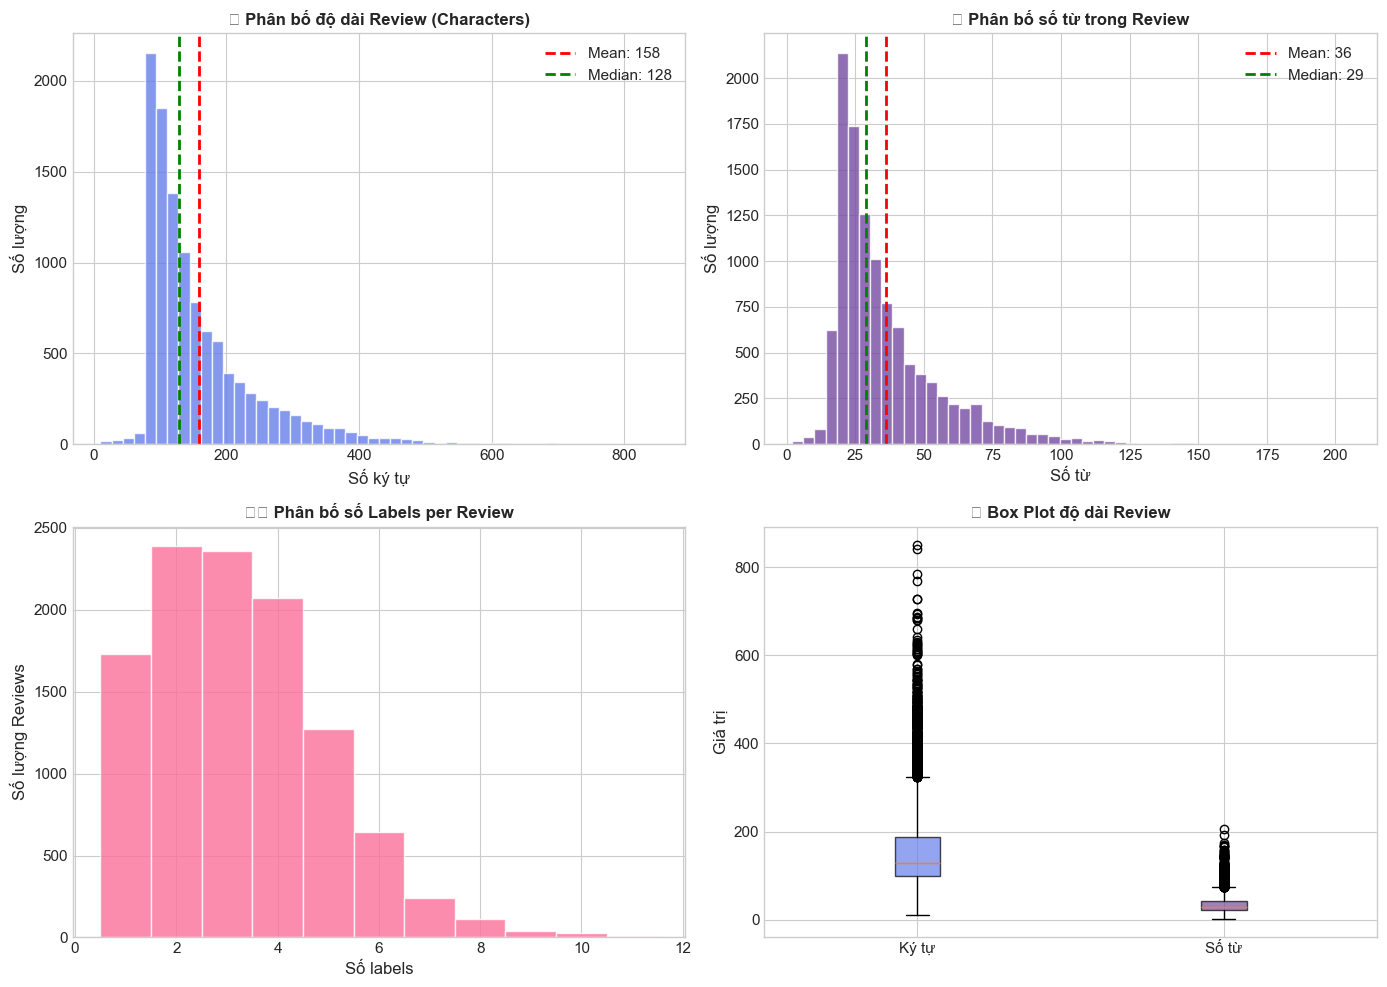

In [13]:
# Visualize phân bố độ dài
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram độ dài (characters)
axes[0, 0].hist(review_lengths, bins=50, color=COLORS['primary'], edgecolor='white', alpha=0.8)
axes[0, 0].axvline(np.mean(review_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(review_lengths):.0f}')
axes[0, 0].axvline(np.median(review_lengths), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(review_lengths):.0f}')
axes[0, 0].set_title('📏 Phân bố độ dài Review (Characters)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Số ký tự')
axes[0, 0].set_ylabel('Số lượng')
axes[0, 0].legend()

# 2. Histogram số từ
axes[0, 1].hist(word_counts, bins=50, color=COLORS['secondary'], edgecolor='white', alpha=0.8)
axes[0, 1].axvline(np.mean(word_counts), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(word_counts):.0f}')
axes[0, 1].axvline(np.median(word_counts), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(word_counts):.0f}')
axes[0, 1].set_title('📝 Phân bố số từ trong Review', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Số từ')
axes[0, 1].set_ylabel('Số lượng')
axes[0, 1].legend()

# 3. Histogram số labels per review
axes[1, 0].hist(labels_per_review, bins=range(1, max(labels_per_review)+2), 
                color='#fa709a', edgecolor='white', alpha=0.8, align='left')
axes[1, 0].set_title('🏷️ Phân bố số Labels per Review', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Số labels')
axes[1, 0].set_ylabel('Số lượng Reviews')

# 4. Box plot so sánh
data_to_plot = [review_lengths, word_counts]
bp = axes[1, 1].boxplot(data_to_plot, labels=['Ký tự', 'Số từ'], patch_artist=True)
colors_box = [COLORS['primary'], COLORS['secondary']]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('📊 Box Plot độ dài Review', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Giá trị')

plt.tight_layout()
plt.show()


### 3.7 Phân bố Aspect-Sentiment Pairs

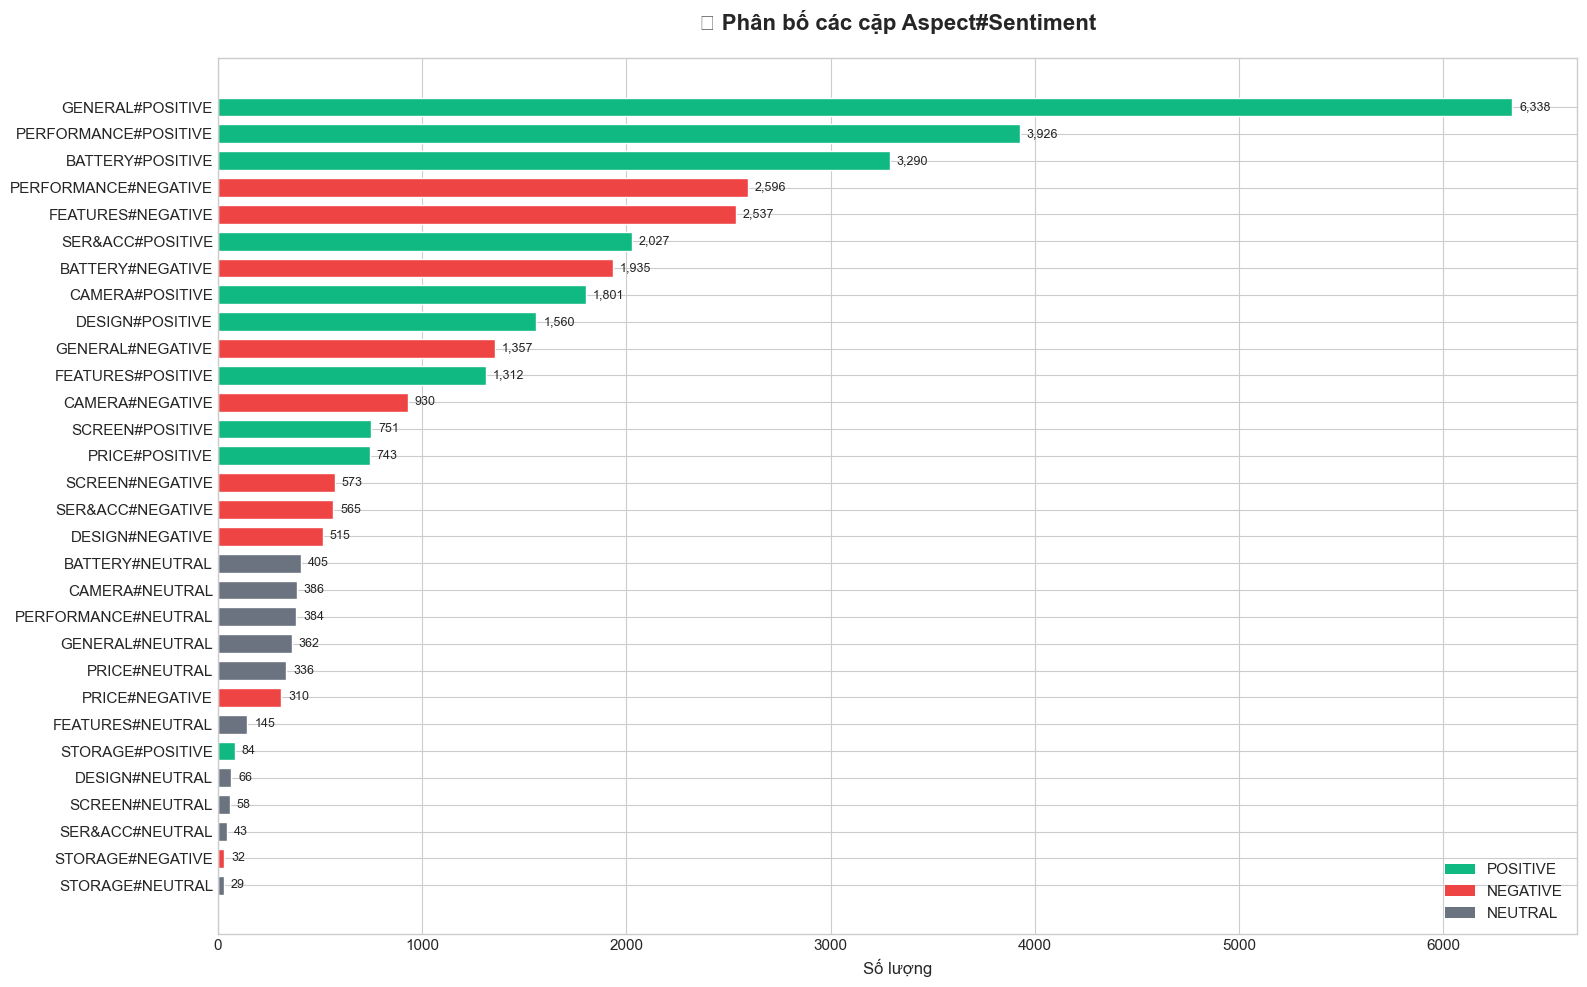

In [14]:
# Phân bố các cặp Aspect-Sentiment
as_counts_sorted = dict(as_counts.most_common())

fig, ax = plt.subplots(figsize=(16, 10))

# Tạo màu dựa trên sentiment
colors_as = []
for label in as_counts_sorted.keys():
    if 'POSITIVE' in label:
        colors_as.append(COLORS['positive'])
    elif 'NEGATIVE' in label:
        colors_as.append(COLORS['negative'])
    else:
        colors_as.append(COLORS['neutral'])

y_pos = np.arange(len(as_counts_sorted))
bars = ax.barh(y_pos, list(as_counts_sorted.values()), color=colors_as, 
               edgecolor='white', height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(list(as_counts_sorted.keys()))
ax.invert_yaxis()
ax.set_title('📊 Phân bố các cặp Aspect#Sentiment', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Số lượng', fontsize=12)

# Thêm giá trị
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{int(width):,}',
                xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords='offset points',
                ha='left', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['positive'], label='POSITIVE'),
    Patch(facecolor=COLORS['negative'], label='NEGATIVE'),
    Patch(facecolor=COLORS['neutral'], label='NEUTRAL')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()


---
## 4️⃣ Word Cloud

In [15]:
# Kết hợp tất cả text
all_texts = ' '.join([sample['text'] for sample in all_data])

# Xác định font hỗ trợ tiếng Việt
import os

# Danh sách các font path có thể có
font_paths = [
    'C:/Windows/Fonts/arial.ttf',
    'C:/Windows/Fonts/times.ttf',
    'C:/Windows/Fonts/calibri.ttf',
    'C:/Windows/Fonts/tahoma.ttf',
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',  # Linux
    None  # Default font
]

font_path = None
for fp in font_paths:
    if fp and os.path.exists(fp):
        font_path = fp
        break

In [16]:
# Định nghĩa stopwords tiếng Việt
vietnamese_stopwords = set([
    'và', 'của', 'là', 'có', 'được', 'cho', 'với', 'này', 'đã', 'để', 'trong', 'về',
    'theo', 'như', 'không', 'từ', 'một', 'khi', 'các', 'những', 'ra', 'tại', 'lại',
    'còn', 'cũng', 'đến', 'trên', 'nên', 'hay', 'thì', 'rất', 'nếu', 'bị', 'quá',
    'cái', 'con', 'đó', 'mà', 'thế', 'hơn', 'phải', 'vì', 'do', 'sau', 'nhưng',
    'đây', 'ở', 'lên', 'bạn', 'tôi', 'mình', 'em', 'anh', 'chị', 'ok', 'hết', 'ạ',
    'nhé', 'nha', 'ơi', 'à', 'xong', 'thôi', 'luôn', 'mua', 'mới', 'máy', 'điện',
    'thoại', 'sản', 'phẩm', 'đt', 'sp', 'shop', 'tgdd', 'thegioididong', 'dienmay'
])

def create_wordcloud(text, title, colormap='viridis', max_words=150):
    """Tạo Word Cloud với cấu hình tốt cho tiếng Việt"""
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        max_words=max_words,
        colormap=colormap,
        font_path=font_path,
        stopwords=vietnamese_stopwords,
        min_font_size=10,
        max_font_size=150,
        prefer_horizontal=0.8,
        relative_scaling=0.5
    ).generate(text)
    
    return wordcloud

### 4.1 Word Cloud - Toàn bộ Dataset

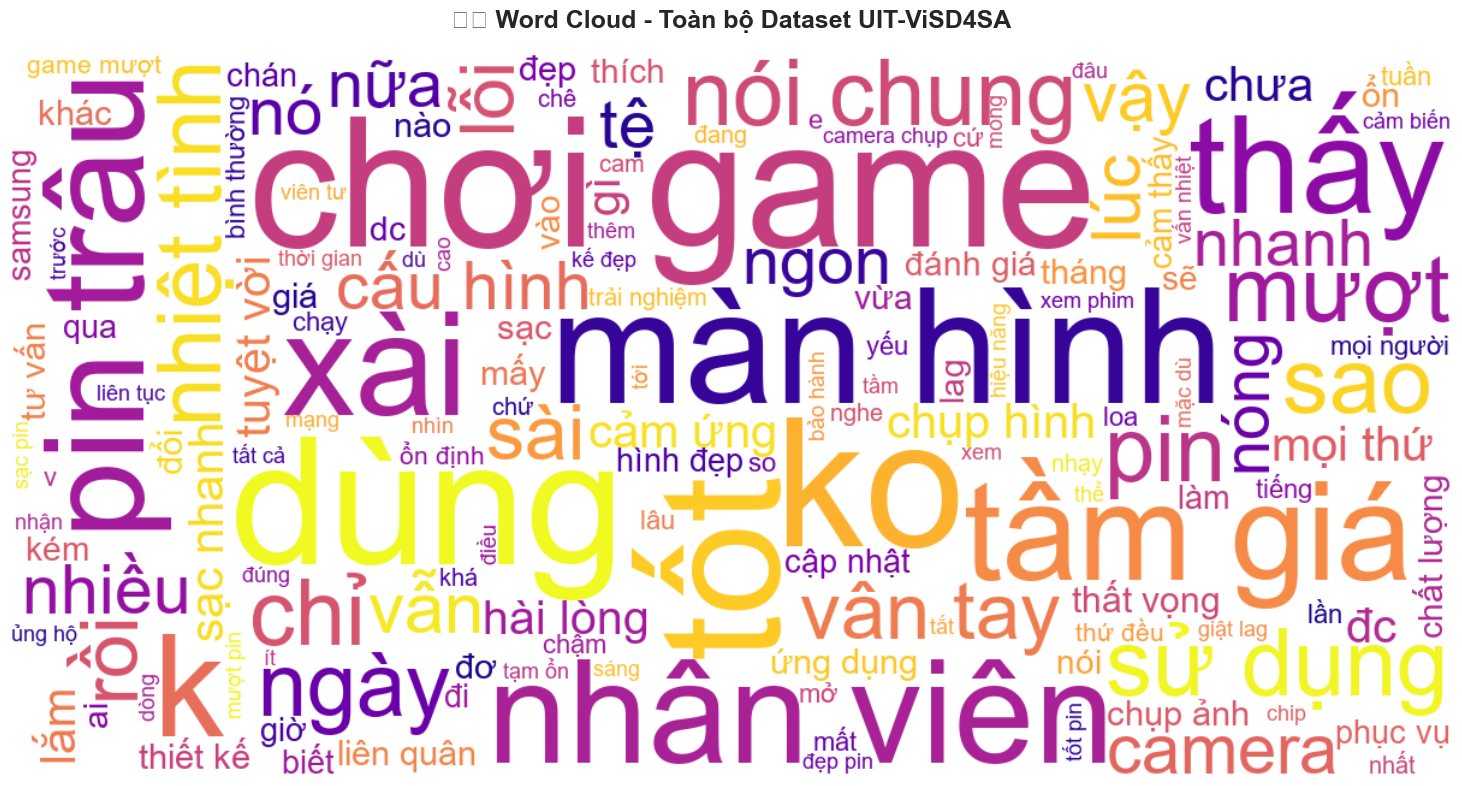

In [17]:
# Word Cloud cho toàn bộ data
fig, ax = plt.subplots(figsize=(16, 8))

wc_all = create_wordcloud(all_texts, 'Toàn bộ Dataset', colormap='plasma')
ax.imshow(wc_all, interpolation='bilinear')
ax.axis('off')
ax.set_title('☁️ Word Cloud - Toàn bộ Dataset UIT-ViSD4SA', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


### 4.2 Word Cloud theo Sentiment

In [18]:
# Tách text theo sentiment
positive_texts = []
negative_texts = []
neutral_texts = []

for sample in all_data:
    text = sample['text']
    for label in sample['labels']:
        start, end, label_str = label
        span_text = text[start:end]
        sentiment = label_str.split('#')[1]
        
        if sentiment == 'POSITIVE':
            positive_texts.append(span_text)
        elif sentiment == 'NEGATIVE':
            negative_texts.append(span_text)
        else:
            neutral_texts.append(span_text)

print(f"📊 Số lượng spans:")
print(f"   Positive: {len(positive_texts):,}")
print(f"   Negative: {len(negative_texts):,}")
print(f"   Neutral: {len(neutral_texts):,}")

📊 Số lượng spans:
   Positive: 21,832
   Negative: 11,350
   Neutral: 2,214


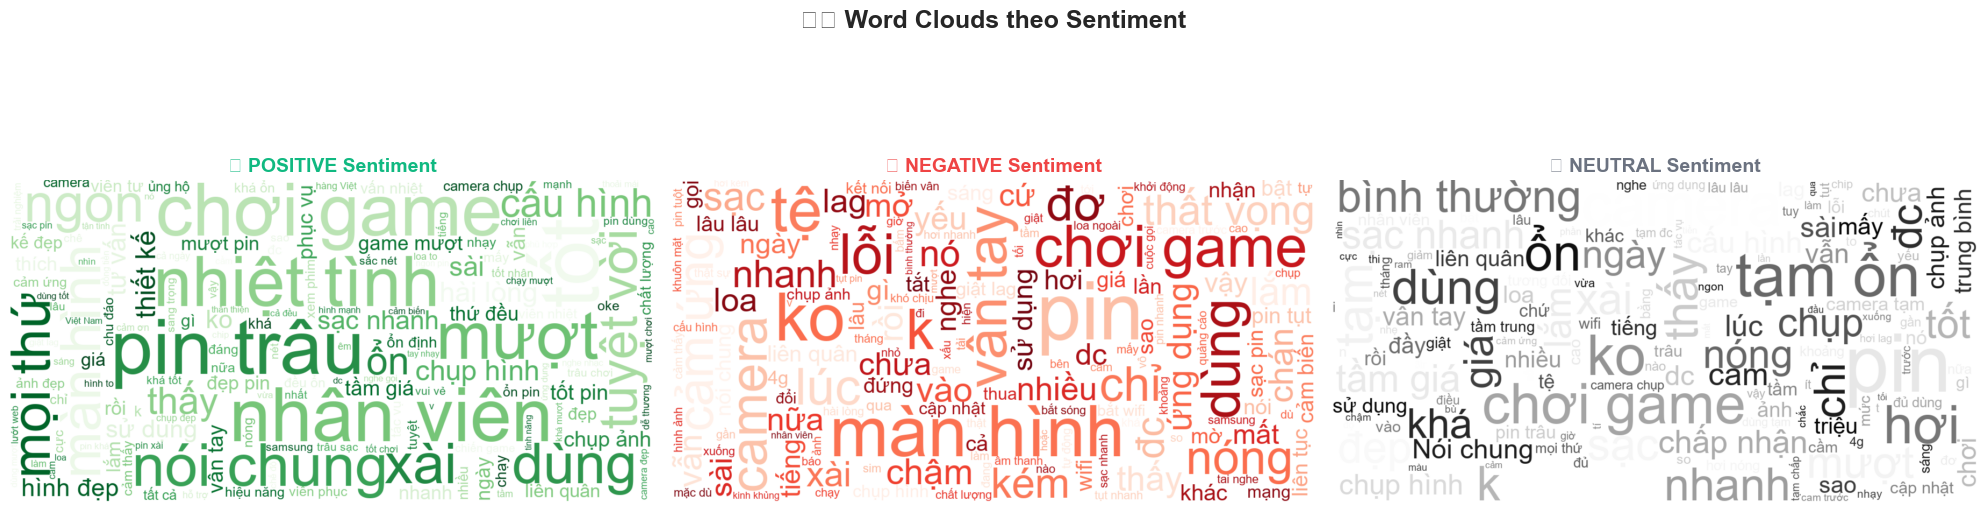

In [19]:
# Word Cloud cho từng sentiment
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Positive
wc_positive = create_wordcloud(' '.join(positive_texts), 'Positive', colormap='Greens')
axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('🟢 POSITIVE Sentiment', fontsize=14, fontweight='bold', color=COLORS['positive'])

# Negative
wc_negative = create_wordcloud(' '.join(negative_texts), 'Negative', colormap='Reds')
axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('🔴 NEGATIVE Sentiment', fontsize=14, fontweight='bold', color=COLORS['negative'])

# Neutral
wc_neutral = create_wordcloud(' '.join(neutral_texts), 'Neutral', colormap='Greys')
axes[2].imshow(wc_neutral, interpolation='bilinear')
axes[2].axis('off')
axes[2].set_title('⚪ NEUTRAL Sentiment', fontsize=14, fontweight='bold', color=COLORS['neutral'])

plt.suptitle('☁️ Word Clouds theo Sentiment', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.3 Word Cloud theo Aspect

In [20]:
# Tách text theo aspect
aspect_texts = {aspect: [] for aspect in set(all_aspects)}

for sample in all_data:
    text = sample['text']
    for label in sample['labels']:
        start, end, label_str = label
        span_text = text[start:end]
        aspect = label_str.split('#')[0]
        aspect_texts[aspect].append(span_text)

print("📊 Số lượng spans theo Aspect:")
for aspect, texts in sorted(aspect_texts.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"   {aspect}: {len(texts):,}")

📊 Số lượng spans theo Aspect:
   GENERAL: 8,057
   PERFORMANCE: 6,906
   BATTERY: 5,630
   FEATURES: 3,994
   CAMERA: 3,117
   SER&ACC: 2,635
   DESIGN: 2,141
   PRICE: 1,389
   SCREEN: 1,382
   STORAGE: 145


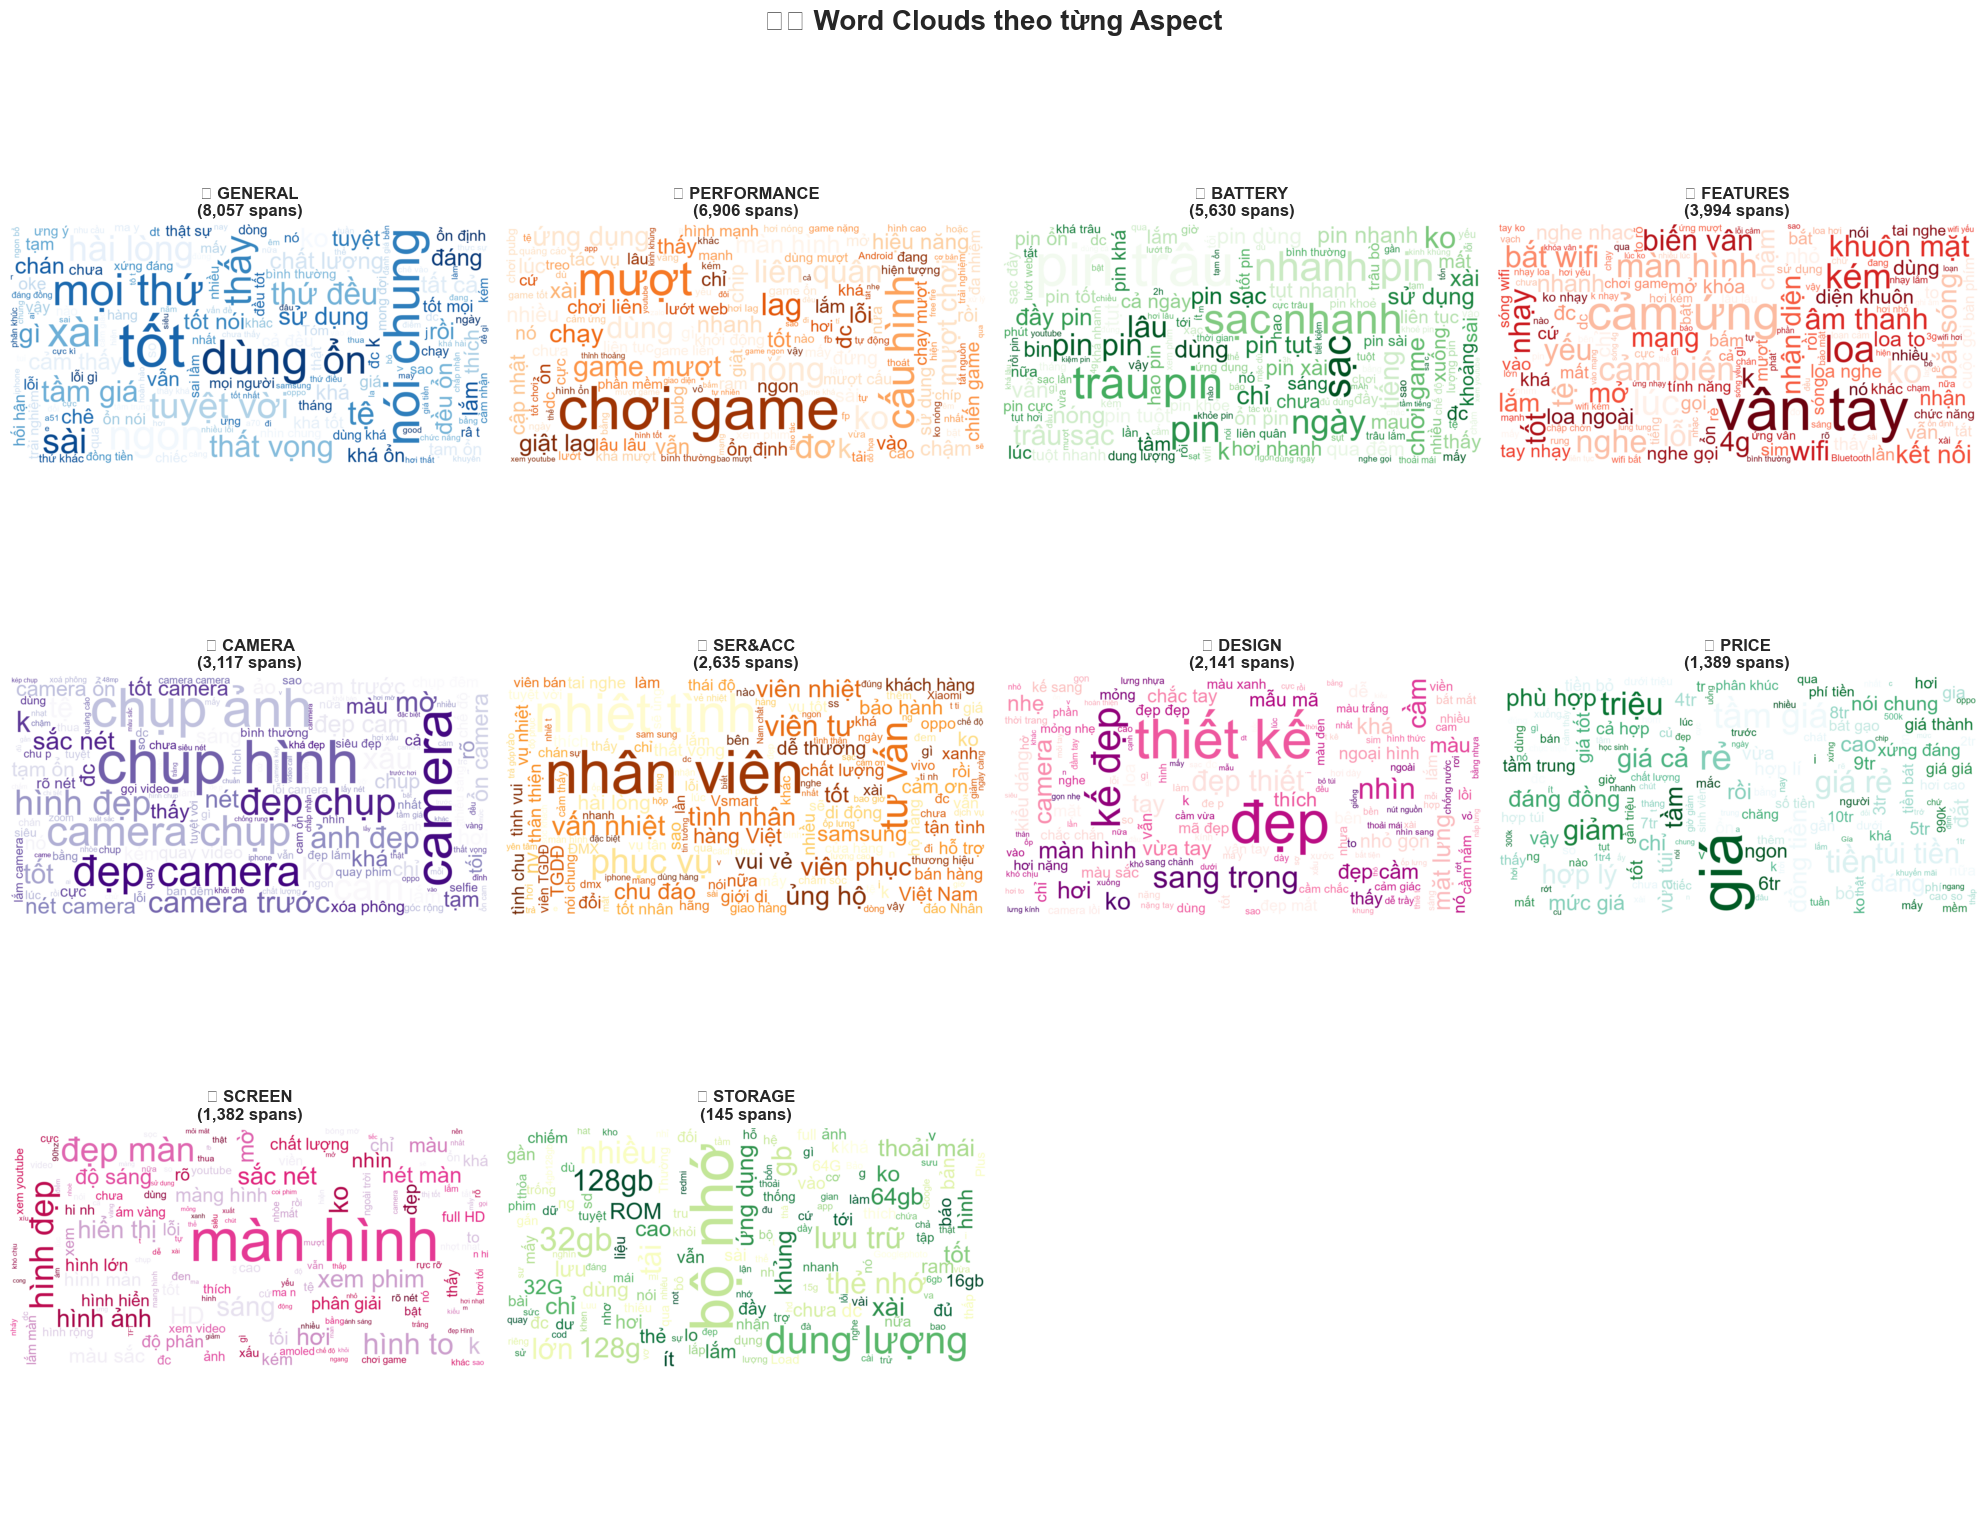

In [21]:
# Word Cloud cho từng Aspect
colormaps = ['Blues', 'Oranges', 'Greens', 'Reds', 'Purples', 
             'YlOrBr', 'RdPu', 'BuGn', 'PuRd', 'YlGn']

n_aspects = len(aspect_texts)
n_cols = 4
n_rows = (n_aspects + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

# Sắp xếp theo số lượng
sorted_aspects = sorted(aspect_texts.items(), key=lambda x: len(x[1]), reverse=True)

for i, (aspect, texts) in enumerate(sorted_aspects):
    if texts:
        wc = create_wordcloud(' '.join(texts), aspect, colormap=colormaps[i % len(colormaps)])
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'📌 {aspect}\n({len(texts):,} spans)', fontsize=12, fontweight='bold')

# Ẩn các axes không sử dụng
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('☁️ Word Clouds theo từng Aspect', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
